# Single value deconvolution of replication timing

May 6, 2024

Goal: Can we deconvolve a single value (position in S/G2M) where replication occurs for each 10k window?


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [146]:
from src.mnase_replication_timing_analysis import MNaseOriginAnalysis

mnase_analysis_rep1 = MNaseOriginAnalysis(replicate=1)
mnase_analysis_rep1.compute_bin_curves()

mnase_analysis_rep2 = MNaseOriginAnalysis(replicate=2)
mnase_analysis_rep2.compute_bin_curves()

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:08.510
1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:16.287


In [147]:
mnase_analysis_rep1.compute_replication_timing()
mnase_analysis_rep2.compute_replication_timing()

In [148]:
from src.stepwise_replication_solver import StepReplicationChromatinDeconvolveSolver

# todo: add replication 2
solver = StepReplicationChromatinDeconvolveSolver(mnase_analysis_rep1, mnase_analysis_rep2)

In [183]:
solver.set_chrom(10)

In [189]:
from src.timer import Timer

"""
Deconvolve all of the bins for a chromosome one at a time. The
deconvolved problem runs faster by running the solver independently
rather than all together. Possibly because the solver doesn't recognize
the independence of the different problems..

todo: is this true for the chromatin gene deconvolutions as well?
"""
timer = Timer()

n = len(solver.chr_genes)

all_fs = None
for bin_idx in np.arange(n):
    solver.select_bins([bin_idx])
    solver.solve(verbose=False)
    if bin_idx % 10 == 0:
        timer.print_time(f"{bin_idx}/{n}")
    current_f = solver.f
    if bin_idx == 0:
        all_fs = np.zeros((n, current_f.shape[0]))
    all_fs[bin_idx] = current_f.flatten()
all_fs = all_fs.T

0/340 - 00:00:00.555
10/340 - 00:00:06.418
20/340 - 00:00:12.697
30/340 - 00:00:18.706
40/340 - 00:00:25.137
50/340 - 00:00:31.430
60/340 - 00:00:37.646
70/340 - 00:00:43.983
80/340 - 00:00:50.582
90/340 - 00:00:57.985
100/340 - 00:01:04.769
110/340 - 00:01:10.926
120/340 - 00:01:16.919
130/340 - 00:01:23.309
140/340 - 00:01:29.116
150/340 - 00:01:34.950
160/340 - 00:01:40.992
170/340 - 00:01:47.960
180/340 - 00:01:54.177
190/340 - 00:02:00.920
200/340 - 00:02:07.329
210/340 - 00:02:13.889
220/340 - 00:02:20.113
230/340 - 00:02:26.206
240/340 - 00:02:32.476
250/340 - 00:02:39.275
260/340 - 00:02:45.212
270/340 - 00:02:50.958
280/340 - 00:02:57.244
290/340 - 00:03:03.943
300/340 - 00:03:09.650
310/340 - 00:03:15.645
320/340 - 00:03:21.999
330/340 - 00:03:28.595


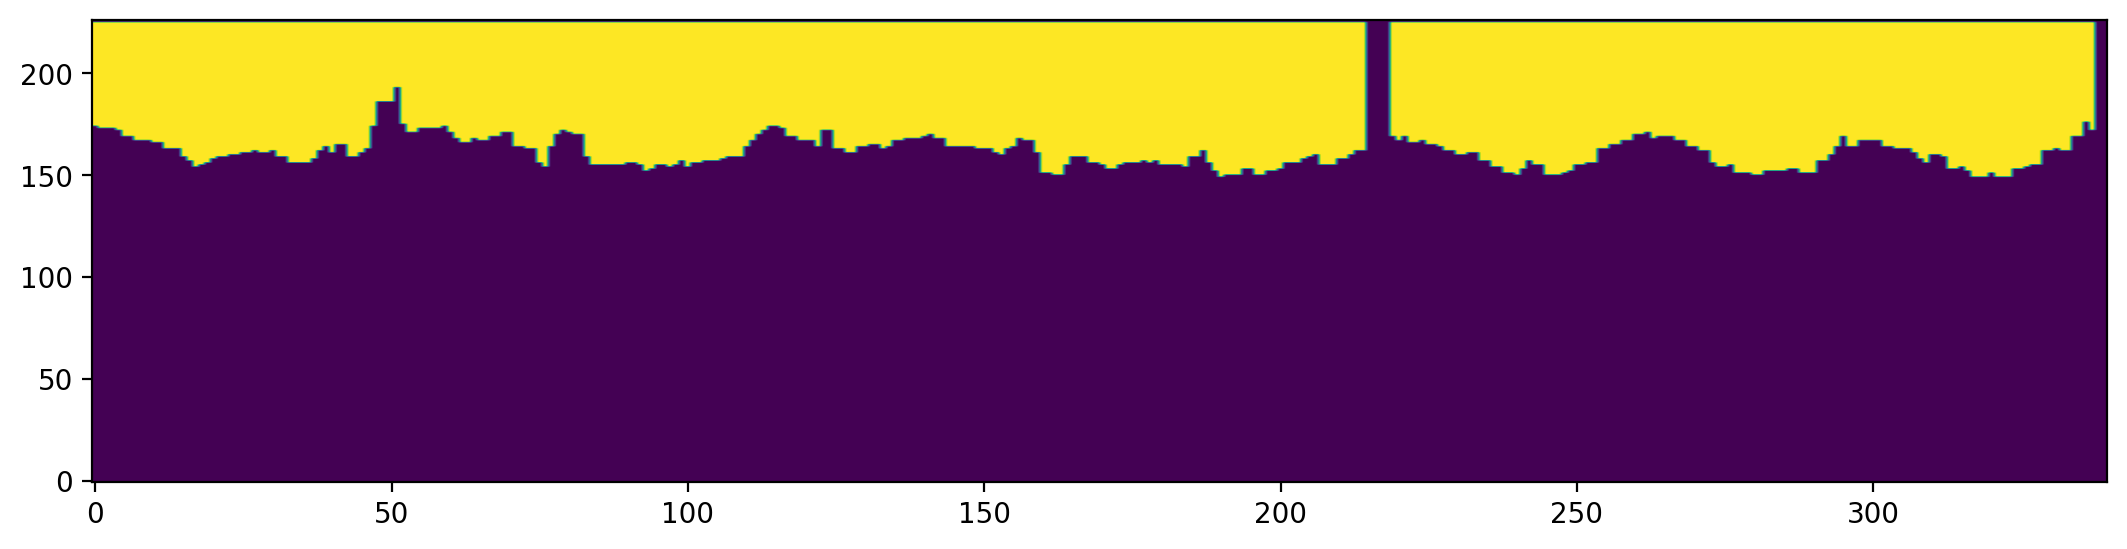

In [190]:
plt.figure(figsize=(13, 3))
plt.imshow(all_fs, origin='lower', aspect='auto')

In [191]:
solver.compute_replication_timing(all_fs)

(20.0, 0.0)

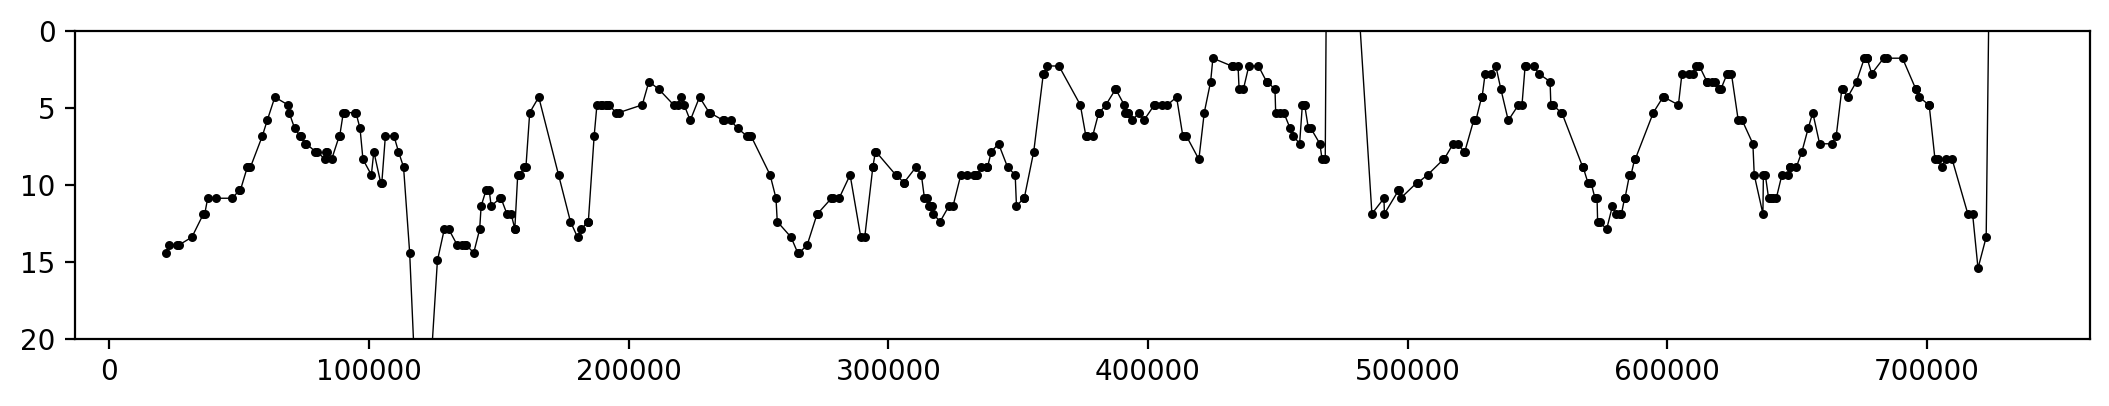

In [200]:
plt.figure(figsize=(13, 2))
plt.plot(solver.chr_genes.TSS, solver.replication_timing_df.replication_time, lw=0.5, c='black')
plt.scatter(solver.chr_genes.TSS, solver.replication_timing_df.replication_time, s=5, c='black')
plt.ylim(20, 0)

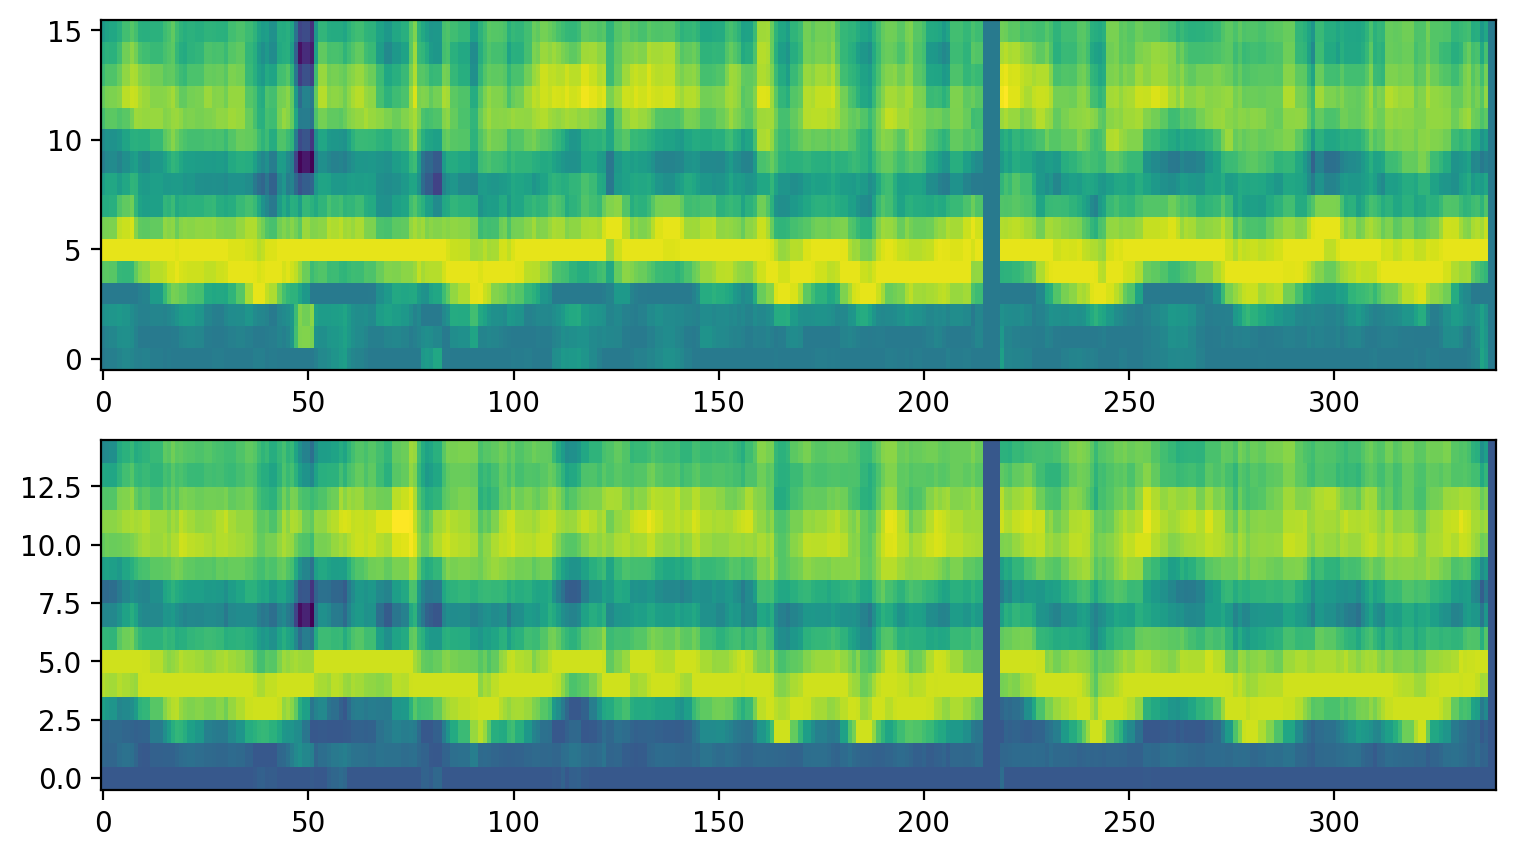

In [196]:
plt.figure(figsize=(9, 5))
plt.subplot(2, 1, 1)
plt.imshow(solver.chr_bin_curves1.T, origin='lower', aspect='auto')
plt.subplot(2, 1, 2)
plt.imshow(solver.chr_bin_curves2.T, origin='lower', aspect='auto')

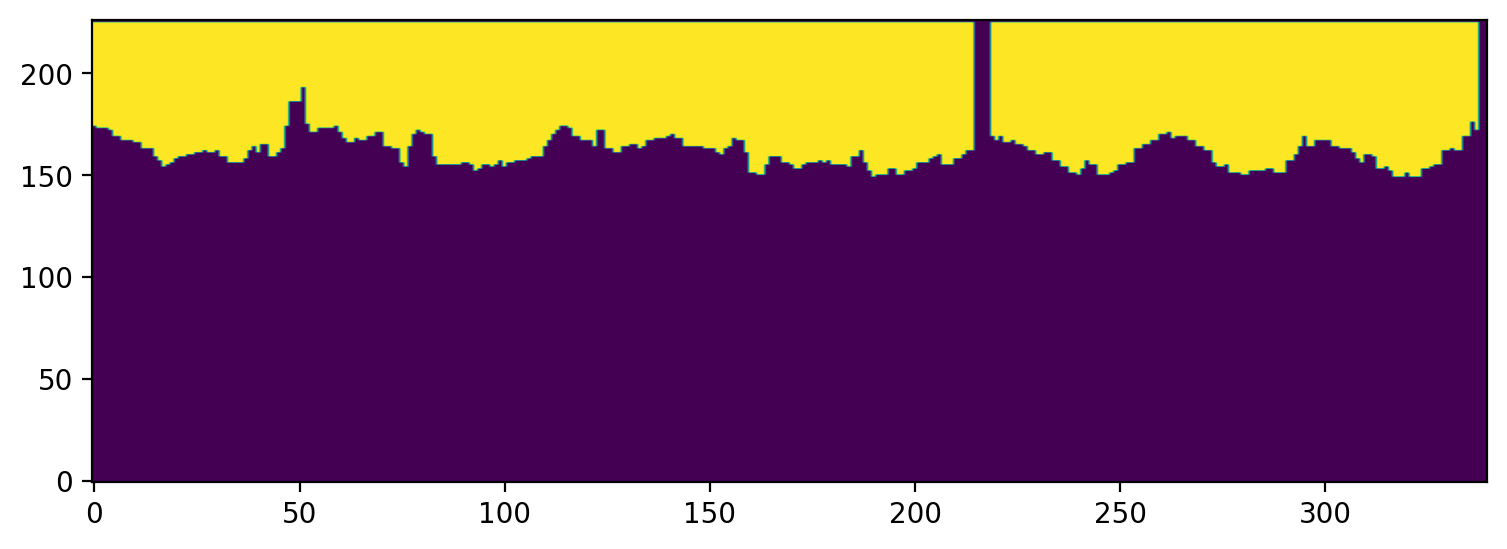

In [197]:
plt.figure(figsize=(9, 3))
plt.imshow(all_fs, origin='lower', aspect='auto')